# EuroCrops vector release: exploratory data analysis for pixel-level crop segmentation

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**Dataset.** The EuroCrops vector release, version 11 (Zenodo record [14094196](https://zenodo.org/records/14094196), concept DOI `10.5281/zenodo.6866846`, CC-BY-SA-4.0). Self-declared agricultural parcel polygons with the harmonised HCAT3 crop taxonomy attached as `EC_hcat_c`, `EC_hcat_n` and `EC_trans_n`. Four countries are downloaded here, all for the **2021 declaration year**: Estonia, Latvia, Lithuania and Portugal. EuroCrops carries a single declaration year per country, so 2021 is what aligns with the Sentinel-2 composites this thesis builds.

**Purpose of this notebook.** Two things. First, to characterise the polygons as an annotation source for a task whose annotation unit is the parcel and whose inference unit is the 10 m pixel: how many pixels a polygon buys, how much of a polygon is boundary, how the class prior changes when it is weighted by area rather than by parcel count, and how many 224 x 224 chips the labels occupy. Second, to compare this release against **EuroCropsML** (Zenodo record [15095445](https://zenodo.org/records/15095445)), the benchmark that supplies the per-parcel time series and the official few-shot splits, so that it is clear which of the two defines a parcel, an identifier and a class label.

**Provenance of every number.** Unless a cell states otherwise, every statistic is computed over all **1,810,723 parcels** of the four countries, not over a sample. Areas, perimeters and centroids are computed in EPSG:3035 (ETRS89-LAEA), so countries are comparable. Two steps are sampled and say so: the validation of the boundary approximation (5,000 parcels per country) and the geometry agreement against EuroCropsML (5,000 parcels per country). Both are seeded with 42.

| Script | What it does | Cached artefact |
|---|---|---|
| `scripts/data/fetch_eurocrops.py` | downloads, md5-verifies, unpacks and converts the release to GeoParquet | `data/eurocrops/parquet/<CC>_2021.parquet` |
| `scripts/data/fetch_eurocropsml.py` | the same for the EuroCropsML benchmark | `data/eurocropsml/` |
| `results/eda/eurocrops/_vector_analysis.py` | per-parcel geometry metrics, figures 01 to 12 | `findings.json`, `cache/*.parquet` |
| `results/eda/eurocrops/_ml_comparison.py` | EuroCrops against EuroCropsML, figures 13 to 18 | `comparison.json` |

## 0. Setup

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
sns.set_theme(context="notebook", style="whitegrid")


def find_repo(start: Path) -> Path:
    """Walk upwards until the repository root is found."""
    for p in [start, *start.parents]:
        if (p / "CLAUDE.md").exists() or (p / ".git").exists():
            return p
    raise RuntimeError("repository root not found")


REPO = find_repo(Path.cwd().resolve())
EDA = REPO / "results" / "eda" / "eurocrops"
CACHE, FIG = EDA / "cache", EDA / "figures"
PARQUET = REPO / "data" / "eurocrops" / "parquet"
DERIVED = REPO / "data" / "eurocrops" / "derived"


def run_script(name: str, *args: str) -> None:
    """Run one of the results/eda/eurocrops scripts in a subprocess."""
    cmd = [sys.executable, str(EDA / name), *args]
    print("running", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=str(REPO))


def cached(path: Path, script: str, *args: str):
    """Load a cached artefact, computing it first if it is missing."""
    if not path.exists():
        run_script(script, *args)
    if path.suffix == ".json":
        return json.loads(path.read_text(encoding="utf-8"))
    return pd.read_parquet(path)


def show(name: str, width: int = 980) -> None:
    display(Image(filename=str(FIG / name), width=width))


def table(df: pd.DataFrame, n: int | None = None) -> None:
    display(df.head(n) if n else df)


findings = cached(EDA / "findings.json", "_vector_analysis.py")
comparison = cached(EDA / "comparison.json", "_ml_comparison.py")
print("repository:", REPO)
print(f"{findings['n_parcels_total']:,} parcels, equal-area CRS {findings['equal_area_crs']}")

repository: /data/private/THESIS - ExplainedGMF4Agri
1,810,723 parcels, equal-area CRS EPSG:3035


## 1. What was downloaded

The four country archives, their coordinate reference systems and their native attribute tables. Nothing has been filtered, reprojected or reclassified: the GeoParquet layers hold every original attribute in the CRS the country published.

,parcels,CRS,HCAT classes,geometry,invalid,attributes,parquet MB
country,,,,,,,
EE,176064,EPSG:4326,128,[Polygon],7,14,354
LV,432188,EPSG:3059,108,[Polygon],0,14,713
LT,1102471,EPSG:4326,22,"[Polygon, MultiPolygon]",1,9,639
PT,100000,EPSG:4326,84,"[Polygon, MultiPolygon]",81,18,40


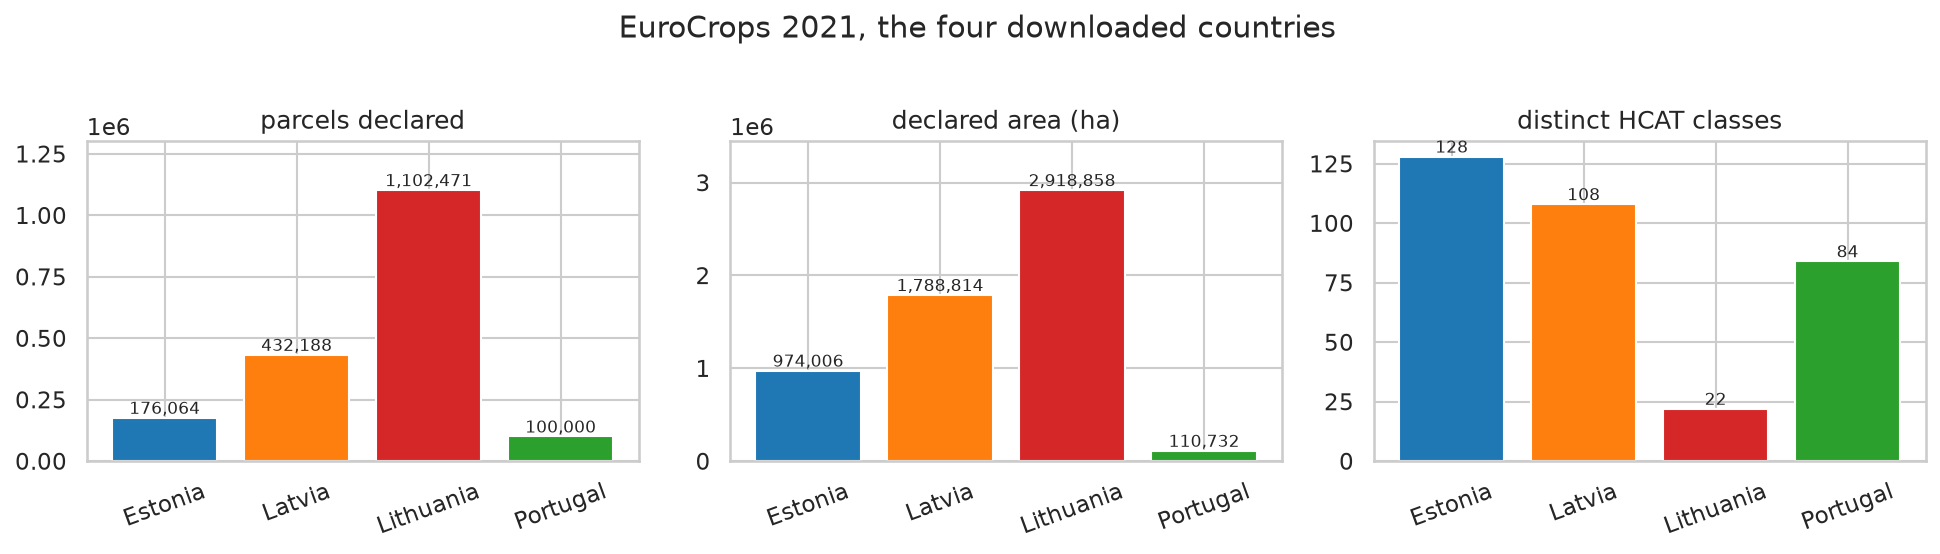

In [2]:
rows = []
for cc in ["EE", "LV", "LT", "PT"]:
    s = json.loads((PARQUET / f"{cc}_2021.summary.json").read_text())
    rows.append({
        "country": s["country"], "parcels": s["n_parcels"], "CRS": s["crs"],
        "HCAT classes": s["n_hcat_classes"], "geometry": list(s["geometry_types"]),
        "invalid": s["invalid_geometries"],
        "attributes": len(s["columns"]) - 1,
        "parquet MB": round(s["parquet_bytes"] / 1e6),
    })
table(pd.DataFrame(rows).set_index("country"))
show("01_inventory.png", width=1000)

Latvia and Estonia are the two countries `CLAUDE.md` builds first; Lithuania is downloaded because it is the obvious fourth Baltic transfer cell and is also 2021; Portugal is the third EuroCropsML country.

Three observations that shape everything below:

- **Lithuania is the largest by parcel count (1,102,471) and the poorest by label depth (22 HCAT classes).** Its national declaration scheme distinguishes only broad groups, so a Lithuanian pixel can be supervised as *winter cereals* but not as *winter wheat*. Estonia, one sixth the size, carries 128 classes.
- **Portugal is exactly 100,000 features.** A round number of that kind is consistent with a sampled release rather than the full national declaration, and it should be treated as a sample until the EuroCrops wiki confirms otherwise.
- **The CRS differs per country**, EPSG:4326 for Estonia, Lithuania and Portugal and EPSG:3059 for Latvia, so any cross-country statistic must reproject first. Everything in this notebook is computed in EPSG:3035.

## 2. From polygons to pixels

The label budget of this thesis is counted in polygons, because one polygon is one human annotation action. The loss, however, is computed per pixel. The conversion between the two is a property of the parcels, and it differs by a factor of eleven between these countries.

parcel size in 10 m pixels


,n,mean,p05,p25,p50,p75,p95
country,,,,,,,
Estonia,176064.0,553.2,14.8,90.9,255.2,650.5,2060.7
Latvia,432188.0,413.9,30.1,75.3,185.8,450.5,1522.6
Lithuania,1102471.0,264.8,8.1,34.9,100.5,257.3,1020.5
Portugal,100000.0,110.7,2.9,9.1,22.8,61.5,393.0



share of parcels below a pixel threshold (%)


,lt_10px,lt_100px,lt_1000px
Estonia,3.75,27.01,84.62
Latvia,1.64,32.17,90.34
Lithuania,5.92,49.62,94.82
Portugal,27.68,83.50,97.80


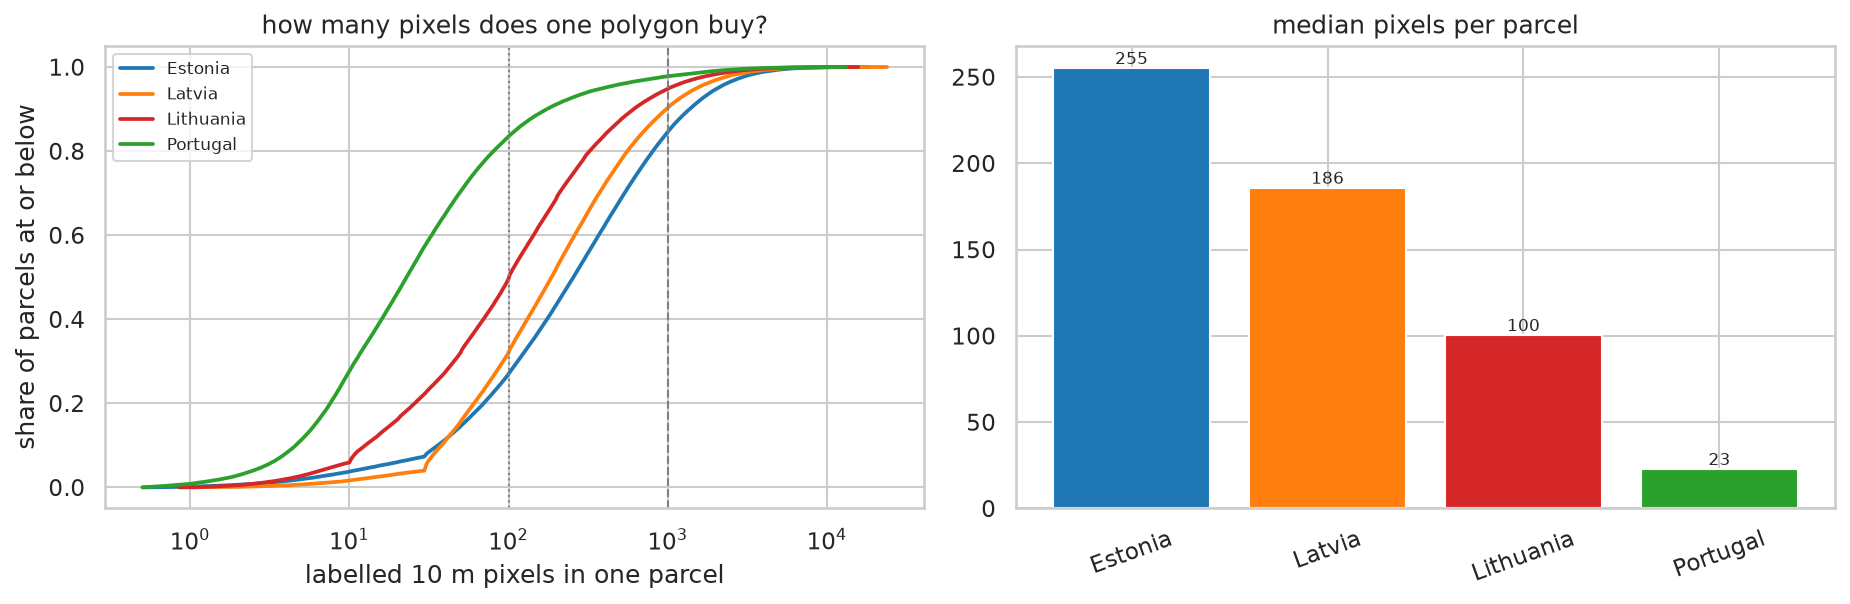

In [3]:
px = pd.DataFrame(findings["pixels_per_parcel"]).T
px.index.name = "country"
print("parcel size in 10 m pixels")
table(px)
print("\nshare of parcels below a pixel threshold (%)")
table(pd.DataFrame(findings["parcels_below_pixel_thresholds_pct"]).T)
show("02_pixels_per_parcel.png", width=1000)

### 2.1 One polygon is a few hundred pixels, except in Portugal

The median parcel holds 255 pixels in Estonia, 186 in Latvia, 100 in Lithuania and 23 in Portugal. The Portuguese median parcel is therefore roughly 11 times smaller than the Estonian one, and 83.5 % of Portuguese parcels hold fewer than one hundred pixels against 27.0 % of Estonian ones.

This is the first concrete consequence of the segmentation reformulation. A per-parcel classifier sees one sample per polygon regardless of its size, so Portugal is merely a country with more parcels per hectare. A segmenter sees every pixel, so Portugal is a country where the same annotation effort buys an order of magnitude less supervision, and where a single 224 x 224 chip contains many more, much smaller objects.

labelled pixels per class implied by a budget of K polygons, at the median parcel size


,Estonia,Latvia,Lithuania,Portugal
K (polygons per class),,,,
1,255,186,100,23
5,1276,929,502,114
10,2552,1858,1005,228
20,5104,3717,2009,457
50,12760,9291,5024,1142
100,25519,18583,10047,2283
200,51038,37165,20095,4566
500,127596,92914,50237,11416


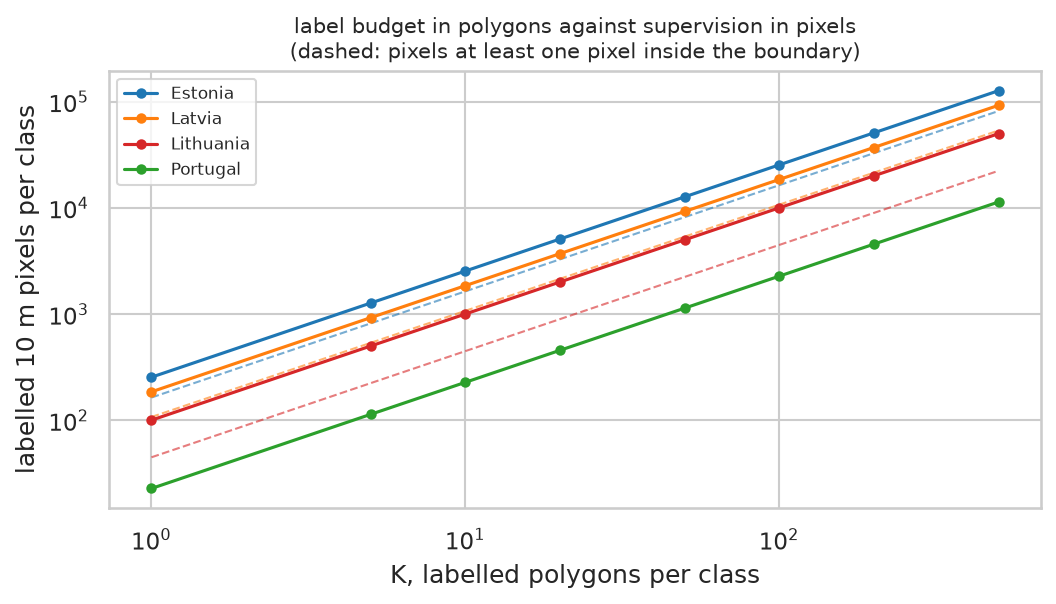

In [4]:
kb = pd.DataFrame(findings["k_budget_pixels"]).T
kb.index.name = "K (polygons per class)"
print("labelled pixels per class implied by a budget of K polygons, at the median parcel size")
table(kb.astype(int))
show("03_k_budget_in_pixels.png", width=760)

### 2.2 What a label budget of K polygons actually buys

At K = 10 polygons per class the supervision is 2,552 labelled pixels in Estonia but only 228 in Portugal. At K = 100 it is 25,519 against 2,283.

The dashed curves in the figure count only pixels at least one pixel inside the boundary, which is the supervision that survives if edge pixels are excluded as mixed. The gap between the solid and the dashed curve is the cost of the mixed-pixel problem, and in Portugal it removes most of the budget.

Two protocol consequences follow, and both belong in `docs/phase1/protocol.md`:

1. **K in polygons is the correct unit for RQ1** because it measures annotation effort, but every learning curve must also report the labelled-pixel count it corresponds to, otherwise the Estonian and Portuguese curves are not the same experiment.
2. **A minimum parcel size may be needed as an inclusion rule.** 27.7 % of Portuguese parcels hold fewer than ten pixels, and a parcel of that size cannot support a meaningful per-pixel loss once boundary pixels are removed.

share of the parcel lying within one 10 m pixel of its own boundary


,n,mean,p05,p25,p50,p75,p95
country,,,,,,,
Estonia,176064.0,0.429,0.112,0.201,0.337,0.600,1.0
Latvia,432188.0,0.464,0.135,0.257,0.408,0.631,1.0
Lithuania,1102471.0,0.590,0.156,0.322,0.540,0.957,1.0
Portugal,100000.0,0.809,0.267,0.631,1.000,1.000,1.0



validation of the perimeter approximation against true erosion (seeded sample)


,n_sampled,median_true_edge_share,median_approx_edge_share,median_ratio_approx_over_true,pearson_r
country,,,,,
Estonia,5000,0.316,0.338,1.051,0.985
Latvia,5000,0.378,0.409,1.069,0.985
Lithuania,5000,0.481,0.535,1.073,0.983
Portugal,5000,0.817,1.000,1.083,0.963


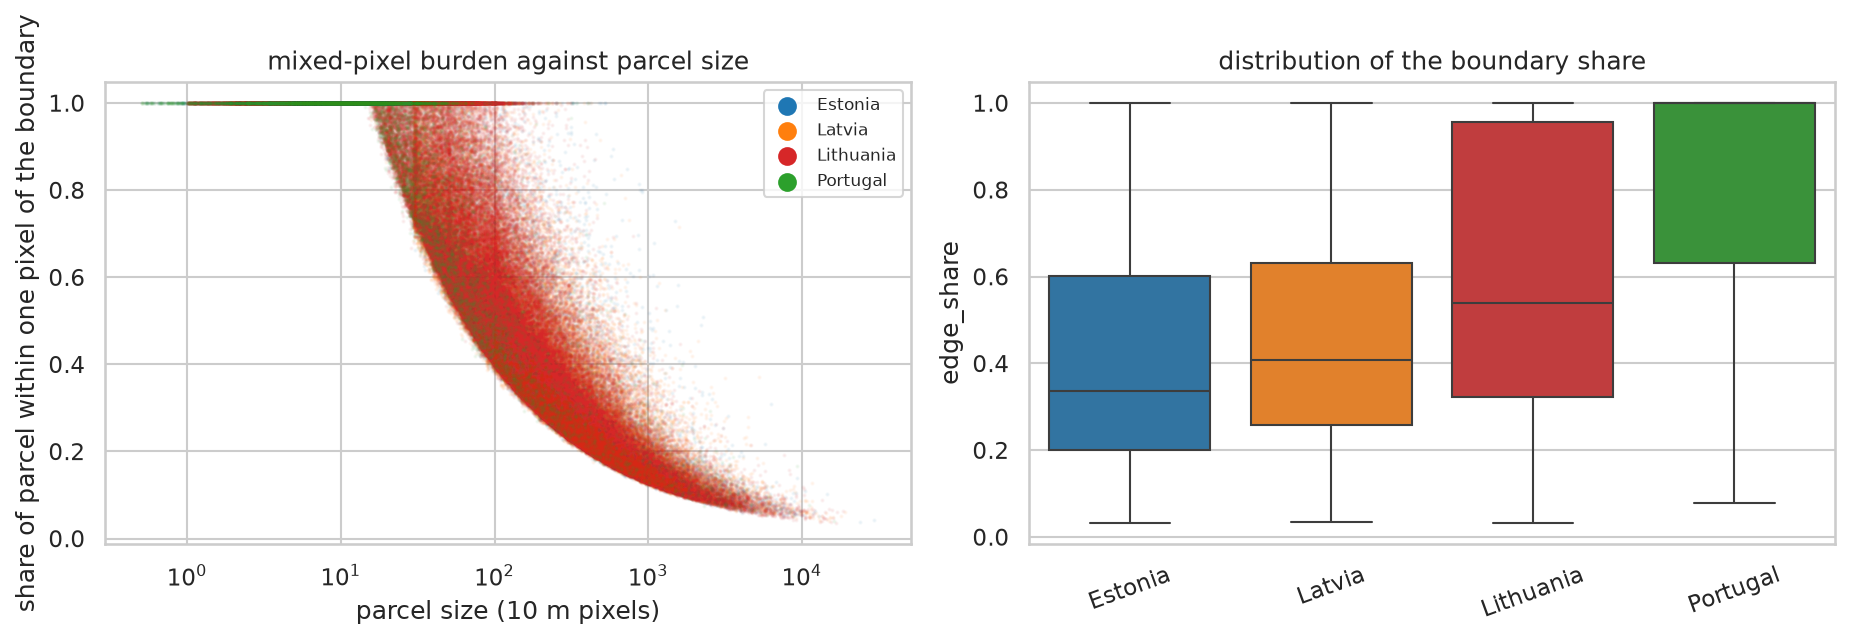

In [5]:
edge = pd.DataFrame(findings["edge_share"]).T
edge.index.name = "country"
print("share of the parcel lying within one 10 m pixel of its own boundary")
table(edge)
print("\nvalidation of the perimeter approximation against true erosion (seeded sample)")
table(pd.DataFrame(findings["edge_approximation_check"]).set_index("country").round(3))
show("04_edge_share.png", width=1000)

### 2.3 Most of a parcel is boundary

The median parcel has 34 % of its area within one pixel of its own boundary in Estonia, 41 % in Latvia, 54 % in Lithuania and 100 % in Portugal. The Portuguese median parcel is entirely boundary: no pixel of it is more than one pixel from an edge.

The share is computed as perimeter x 10 m / area, a first-order approximation. Validated against true erosion by 10 m on a seeded sample of 5,000 parcels per country, it overestimates the true share by 5 to 8 % with a correlation of 0.96 or better, which is accurate enough for the comparisons drawn here and is cheap enough to compute for all 1.8 million parcels.

Mixed pixels are therefore not a marginal correction in this dataset, they are the typical case. Whatever the models do, the evaluation should report crop-type Macro-F1 both over all labelled pixels and over interior pixels only, since the difference between the two is the part of the score that is decided by boundary handling rather than by the encoder.

## 3. The label space

,country,hcat_name,hcat,parcels,parcel_share_pct,area_share_pct,median_pixels,median_edge_share
0,Estonia,pasture_meadow_grassland_grass,3302000000,80857,45.92,29.74,173.04,0.45
1,Estonia,winter_common_soft_wheat,3301010101,13723,7.79,14.07,628.45,0.20
2,Estonia,legumes_harvested_green,3301090300,13543,7.69,8.61,319.41,0.28
3,Estonia,spring_barley,3301010402,10737,6.10,10.11,547.57,0.21
4,Estonia,oats,3301010500,6911,3.93,4.37,365.26,0.27
5,Estonia,clover,3301090303,6877,3.91,3.84,294.15,0.29
6,Estonia,winter_rapeseed_rape,3301060401,6012,3.41,7.02,710.56,0.19
7,Estonia,spring_common_soft_wheat,3301010102,5525,3.14,4.57,476.84,0.23
128,Latvia,pasture_meadow_grassland_grass,3302000000,171646,39.72,26.91,155.73,0.47
129,Latvia,winter_common_soft_wheat,3301010101,50755,11.74,23.97,443.82,0.24


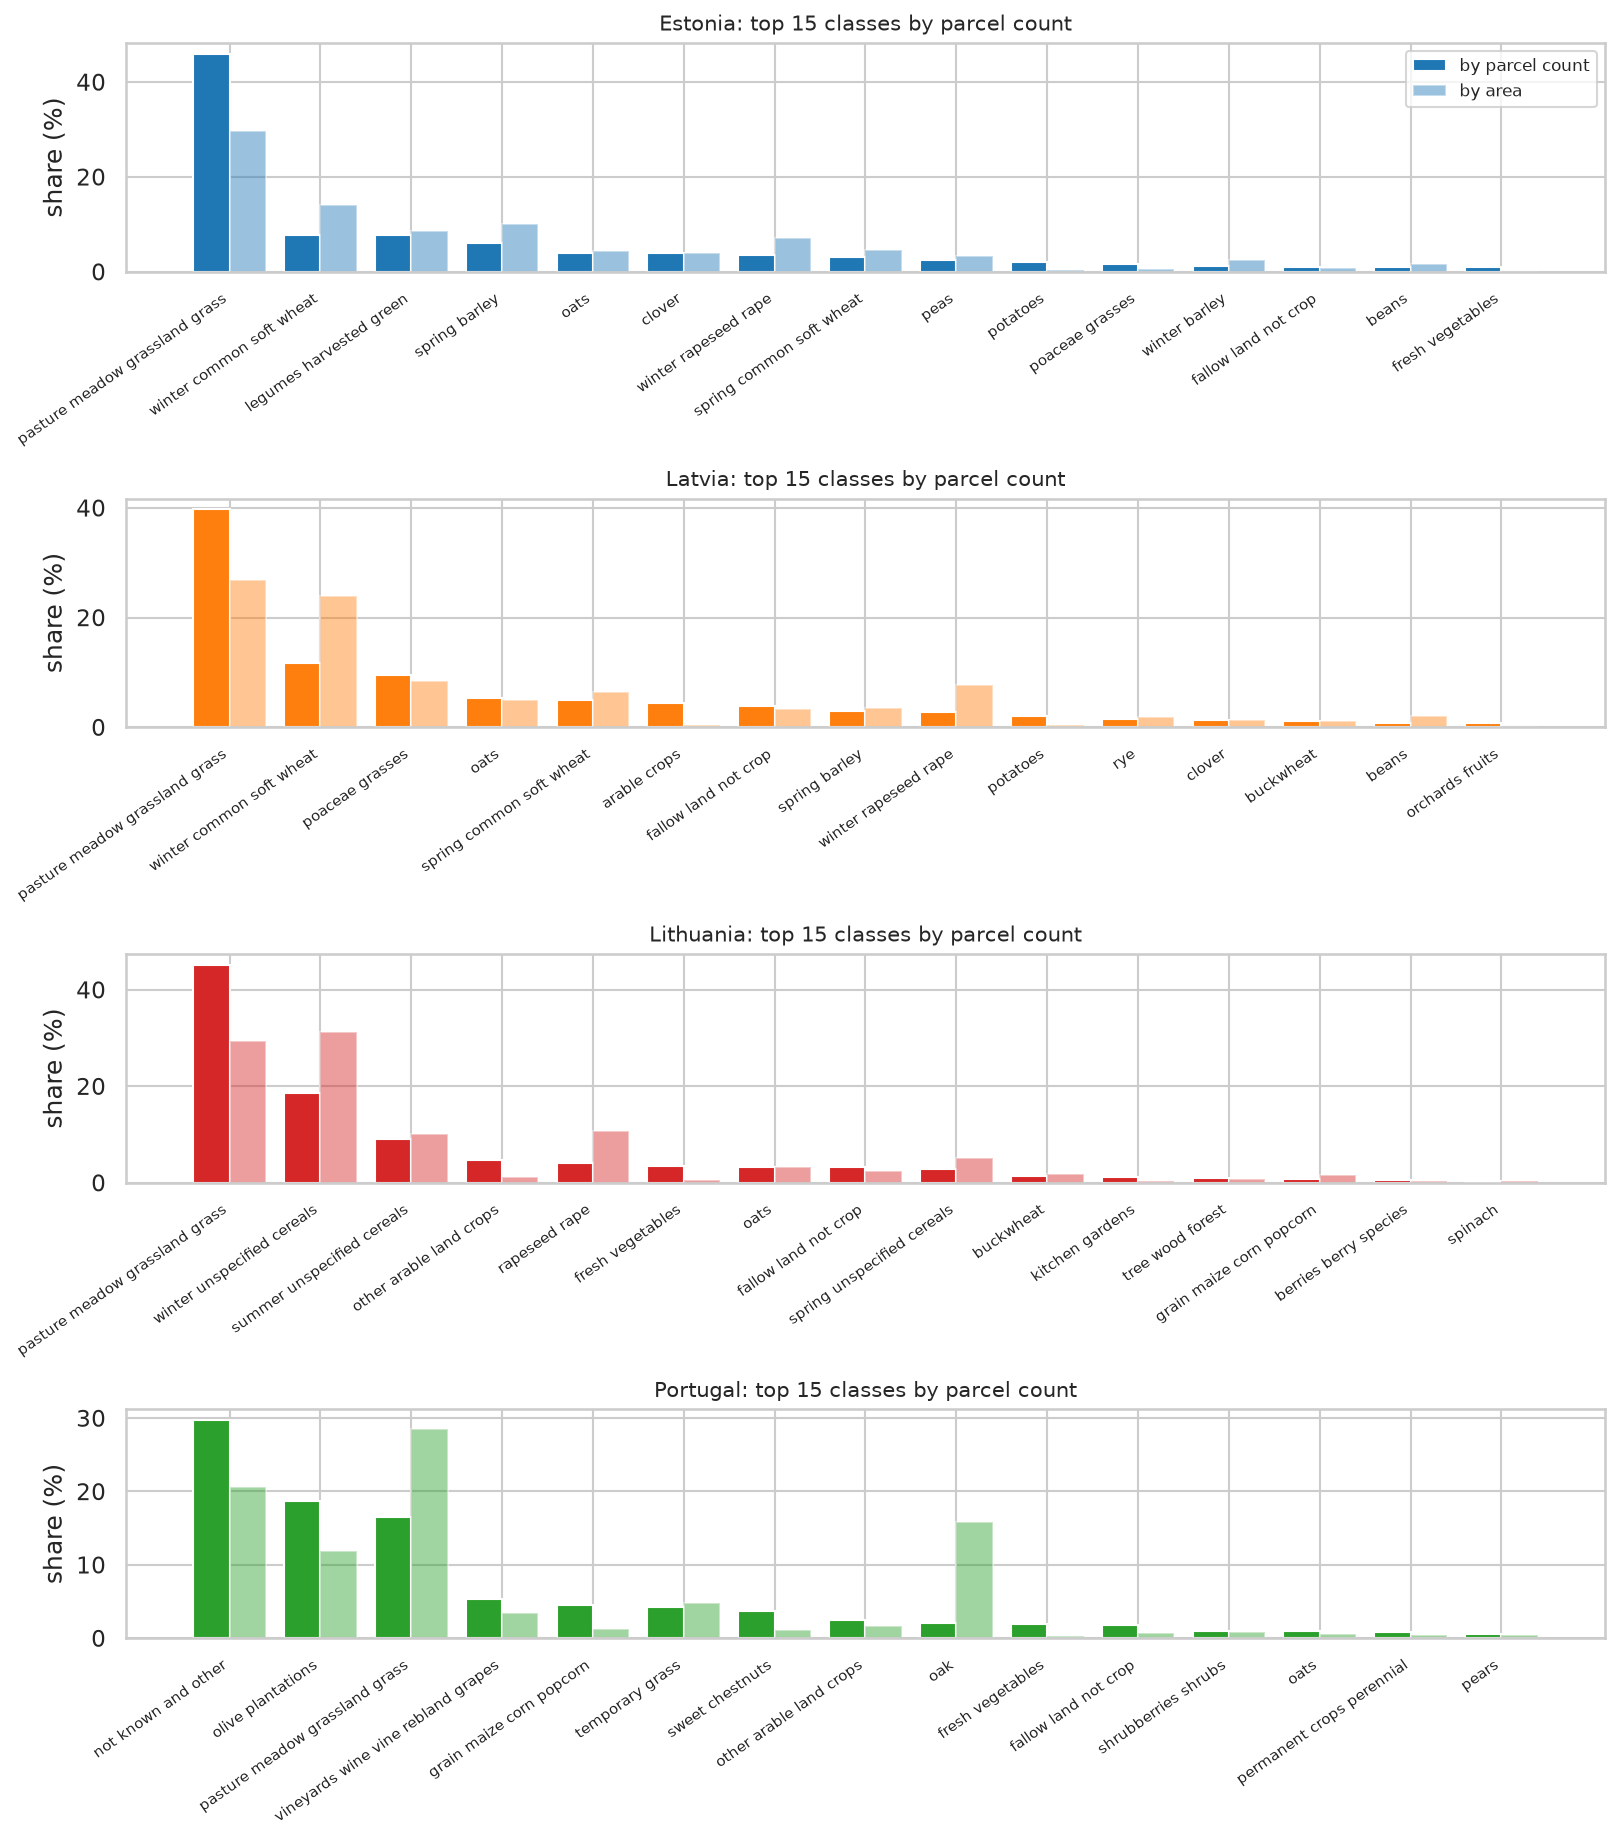

In [6]:
inv_tbl = cached(CACHE / "class_inventory.parquet", "_vector_analysis.py")
top = (inv_tbl.sort_values(["country", "parcels"], ascending=[True, False])
       .groupby("country").head(8)
       [["country", "hcat_name", "hcat", "parcels", "parcel_share_pct", "area_share_pct",
         "median_pixels", "median_edge_share"]])
table(top.round(2), n=32)
show("05_class_prior_count_vs_area.png", width=1000)

### 3.1 The class prior by count is not the class prior by area

The two bars per class in the figure are the same classes weighted two ways: by parcel count, which is what a per-parcel classifier sees, and by area, which is what a per-pixel loss sees. They disagree systematically.

Grassland dominates every Baltic country by count, 45.9 % of Estonian parcels and 39.7 % of Latvian ones, but loses share by area, because grassland parcels are smaller than cereal parcels. In Portugal the effect is stronger and reverses: oak stands hold roughly two per cent of parcels but around sixteen per cent of the declared area, and `pasture_meadow_grassland_grass` almost doubles its share when weighted by area.

For Phase 1 this means the class-balancing decision has to be made explicitly. A pixel-level cross-entropy trained on sparse polygon supervision inherits the **area** prior, not the count prior, unless the loss is weighted per polygon. The choice should be stated in the protocol and held fixed across models, because it changes Macro-F1 by more than most encoder differences are likely to.

class concentration (Gini) and cumulative coverage of the largest classes


,gini_count,gini_area
Estonia,0.926,0.929
Latvia,0.911,0.919
Lithuania,0.761,0.764
Portugal,0.899,0.913


,top1,top5,top10,top20
Estonia,45.9,71.4,86.2,95.5
Latvia,39.7,71.3,87.4,95.5
Lithuania,45.1,81.7,95.8,100.0
Portugal,29.7,74.7,89.2,96.5


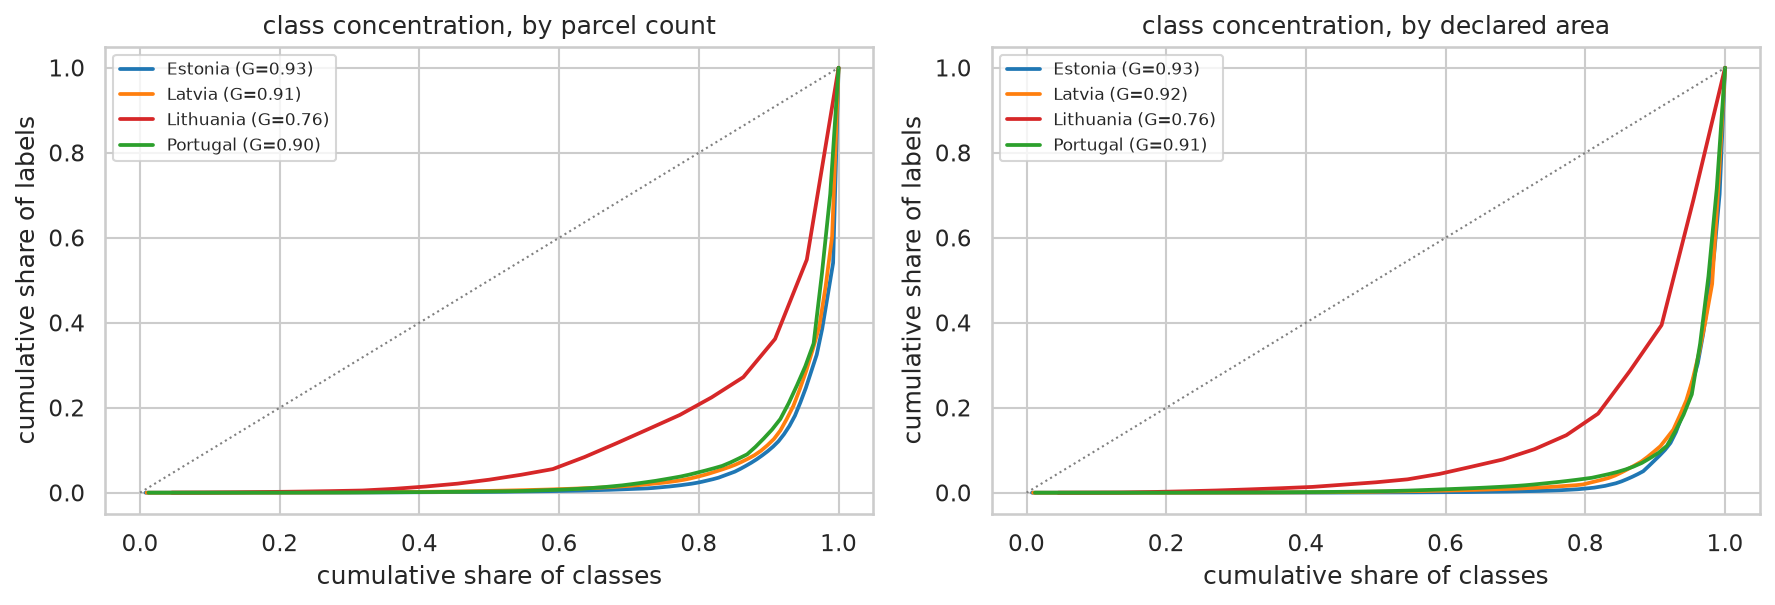

In [7]:
print("class concentration (Gini) and cumulative coverage of the largest classes")
table(pd.DataFrame(findings["class_concentration"]).T)
table(pd.DataFrame(findings["class_coverage_pct"]).T)
show("06_class_concentration.png", width=1000)

### 3.2 The label distribution is extremely concentrated

The Gini coefficient of the class-size distribution is 0.93 for Estonia, 0.91 for Latvia and 0.90 for Portugal, and the twenty largest classes cover between 96 and 100 per cent of all parcels. Weighting by area barely changes the picture, so the concentration is a property of the declarations and not of the parcel sizes.

This is the same conclusion the EuroCropsML analysis reached in `notebooks/01_eurocropsml_eda.ipynb`, and it is why the protocol restricts the benchmark to the most frequent classes per country rather than attempting the full taxonomy.

,Estonia,Latvia,Lithuania,Portugal
minimum parcels per class,,,,
1,128,108,22,84
10,81,91,22,56
50,47,67,22,38
100,35,57,22,31
200,34,45,21,26
500,25,32,20,16
1000,19,25,17,11
5000,8,12,14,4


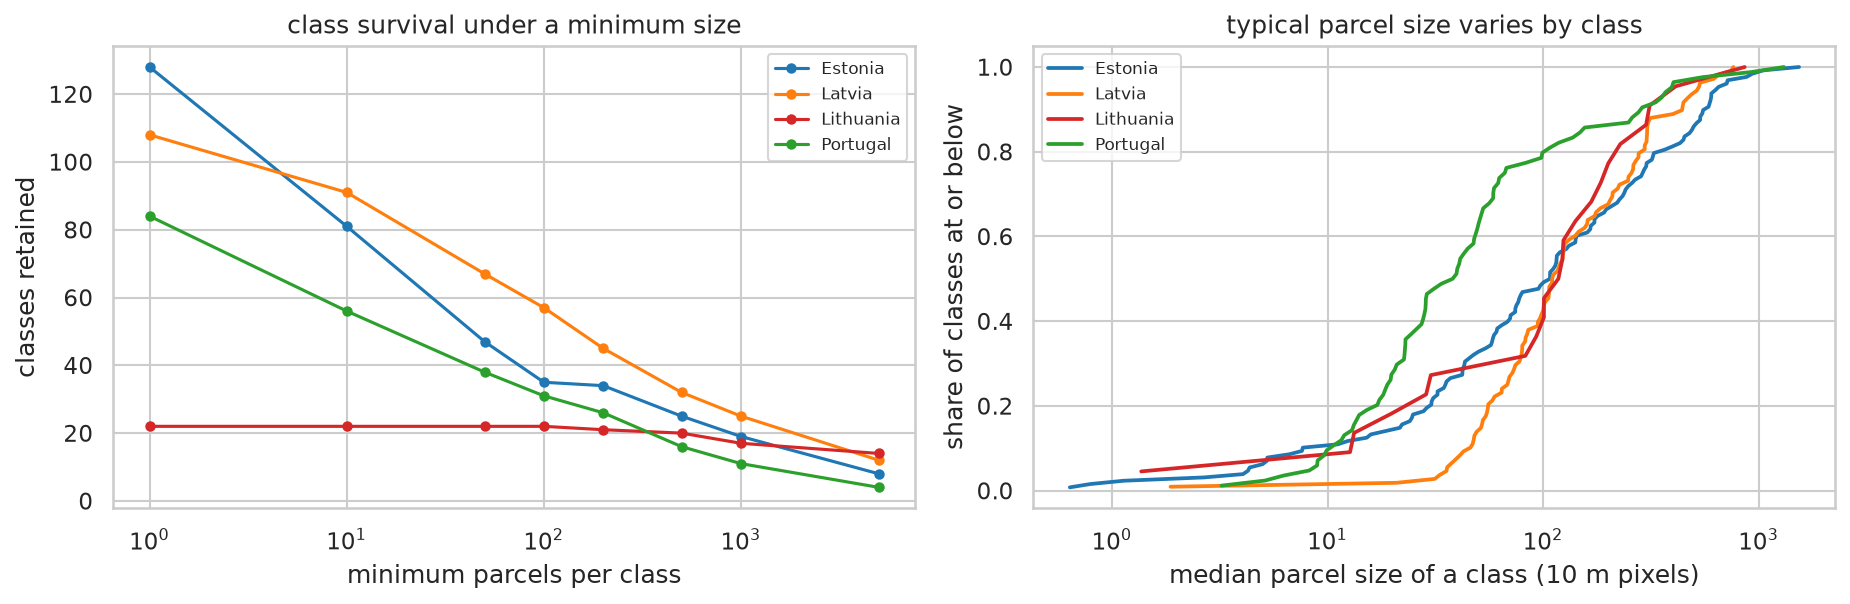

In [8]:
surv = pd.DataFrame(findings["class_survival"]).T
surv.index.name = "minimum parcels per class"
table(surv)
show("12_class_survival.png", width=1000)

### 3.3 How many classes can each country support?

At a minimum of 100 parcels per class, Estonia retains 35 classes, Latvia 57, Lithuania 22 and Portugal 31. At 500 the numbers fall to 25, 32, 20 and 16.

Since the K grid runs to 500 polygons per class and a held-out test set must be drawn on top of that, the 15 to 20 classes per country named in `CLAUDE.md` is the right order of magnitude for the Baltics but is optimistic for Portugal at the upper end of the budget grid. Lithuania is limited by its taxonomy rather than by its size: it has more parcels than the other three combined and never exceeds 22 classes.

classes shared between countries, native HCAT3 codes


,Estonia,Latvia,Lithuania,Portugal
Estonia,128,84,11,45
Latvia,84,108,12,42
Lithuania,11,12,22,12
Portugal,45,42,12,84



rolled up to HCAT level 4


,Estonia,Latvia,Lithuania,Portugal
Estonia,31,29,10,24
Latvia,29,35,11,26
Lithuania,10,11,15,12
Portugal,24,26,12,36



classes present in all four countries: 7
['3301010500', '3301010600', '3301061200', '3301070000', '3301110000', '3301990000', '3302000000']


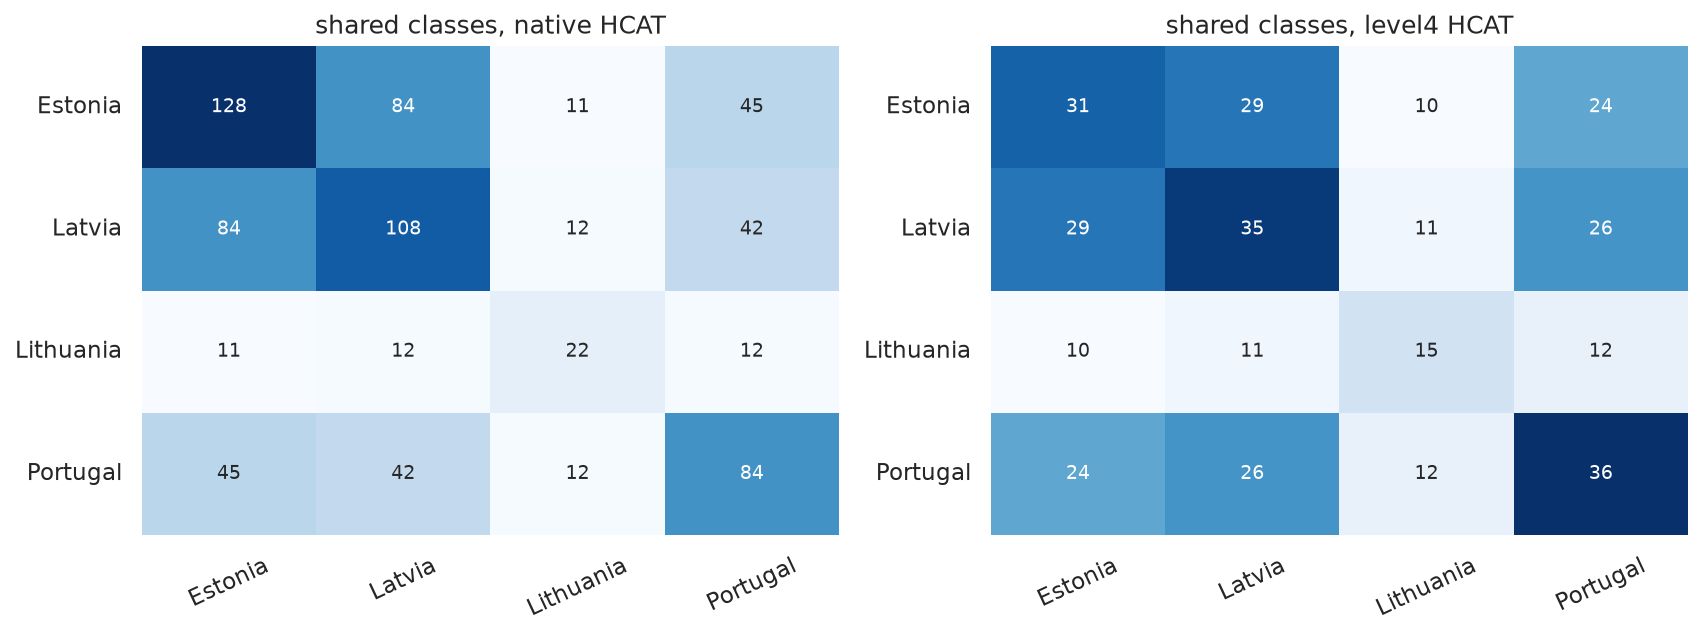

In [9]:
print("classes shared between countries, native HCAT3 codes")
table(pd.DataFrame(findings["class_overlap_native"]))
print("\nrolled up to HCAT level 4")
table(pd.DataFrame(findings["class_overlap_level4"]))
print("\nclasses present in all four countries:", findings["n_classes_shared_by_all_four"])
print([c for c in findings["classes_shared_by_all_four"]])
show("07_class_overlap.png", width=1000)

### 3.4 The cross-country transfer cells are narrow

Only 7 classes are declared in all four countries at the native HCAT3 resolution. Rolling the codes up to HCAT level 4 widens every cell, which is the mechanism `_class_design.py` already uses for EuroCropsML, and it is the reason the transfer experiments in the protocol are defined on the intersection of each pair rather than on a fixed class list.

Lithuania is the awkward partner: its 22 native classes are mostly coarse aggregates that have no exact counterpart in the Estonian or Latvian schemes, so a Lithuanian transfer cell is only meaningful after roll-up.

## 4. Geometry health and attribute quality

,id_column,id_kind,invalid_geometries,multipart,duplicate_parcel_ids,area_below_1_pixel,area_below_10_pixels,no_interior_pixel
Estonia,pollu_id,parcel,6,0,0,303,6609,19021
Latvia,PARCEL_ID,parcel,0,0,1005,0,7082,32618
Lithuania,KZS_NR,field_block,1,1,823580,4,65317,271153
Portugal,OSA_ID,parcel,77,1,0,841,27684,54478


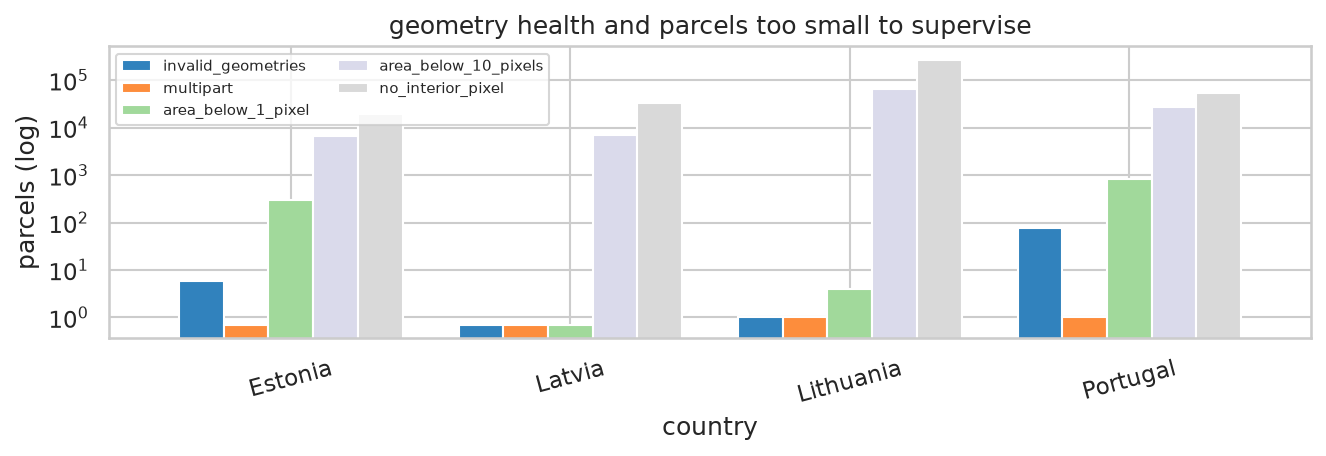

In [10]:
gh = pd.DataFrame(findings["geometry_health"]).T
table(gh)
show("10_geometry_health.png", width=900)

### 4.1 The geometries are clean, the identifiers are not

Invalid geometries are negligible: 6 in Estonia, 0 in Latvia, 1 in Lithuania and 77 in Portugal, out of 1.8 million. Multipart geometries are effectively absent.

The identifiers are a different matter, and this is the trap that matters for the rest of the thesis:

- Estonia's `pollu_id` and Portugal's `OSA_ID` are unique parcel keys.
- Latvia's `PARCEL_ID` carries 1,005 duplicates.
- **Lithuania has no parcel identifier at all.** `KZS_NR` is a field-block number with 278,891 distinct values for 1,102,471 geometries, and `NMA_ID` is a holding number with 120,901. A Lithuanian polygon cannot be addressed through the attribute table, which rules out any join-based workflow for Lithuania and makes it a raster-only country.

The last two rows of the table are about supervision rather than validity: 19,021 Estonian parcels, 32,618 Latvian, 271,153 Lithuanian and 54,478 Portuguese have no pixel left once the boundary pixel is removed.

,attribute,native_unit,n_with_declared_area,median_ratio_computed_ha_over_declared,share_within_5pct,share_below_half
Estonia,pindala_ha,ha,176064,1.0001,98.2,0.0
Latvia,AREA_DECLA,ha,432188,1.0,99.3,0.0
Lithuania,DKL_PLOTAS,ha,1102471,1.0043,92.2,0.02
Portugal,OSA_AREA,m2,100000,0.9999,100.0,0.0


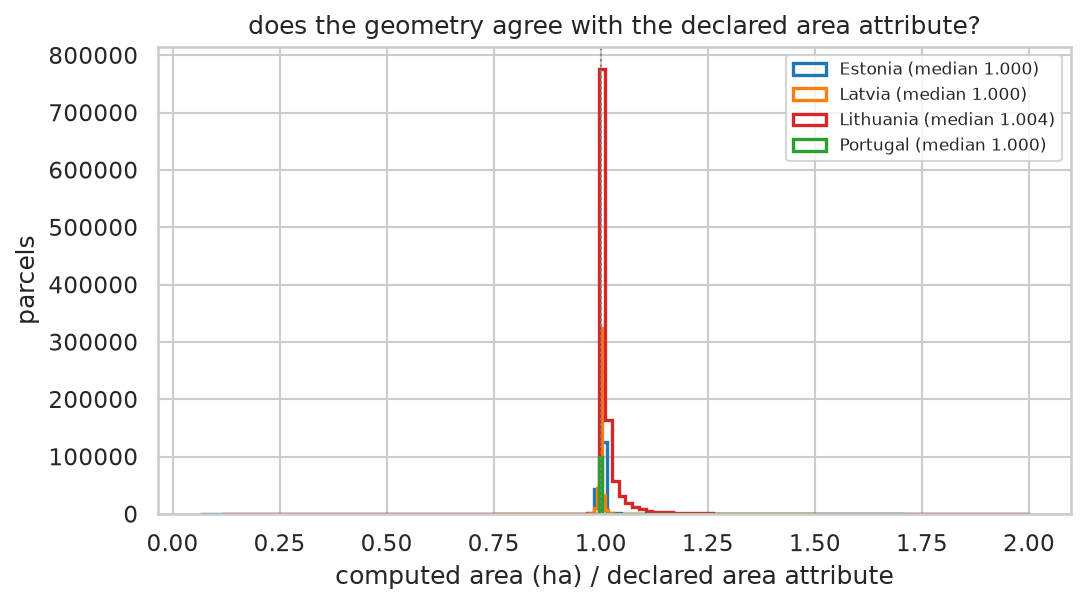

In [11]:
table(pd.DataFrame(findings["declared_area_consistency"]).T)
show("11_declared_vs_computed_area.png", width=760)

### 4.2 The declared-area attribute agrees with the geometry, once the units are right

The area computed from the geometry matches the declared-area attribute for 98.2 % of Estonian parcels, 99.3 % of Latvian, 92.2 % of Lithuanian and 100.0 % of Portuguese ones, within five per cent.

**Portugal reports `OSA_AREA` in square metres while every other country reports hectares.** Taken at face value the Portuguese ratio is 1e-4, which looks like catastrophic disagreement and is in fact a unit. The conversion is now declared in `_vector_analysis.py` and recorded in `data/README.md`; anyone reading the shapefile directly should apply it themselves.

## 5. Spatial layout and the export budget

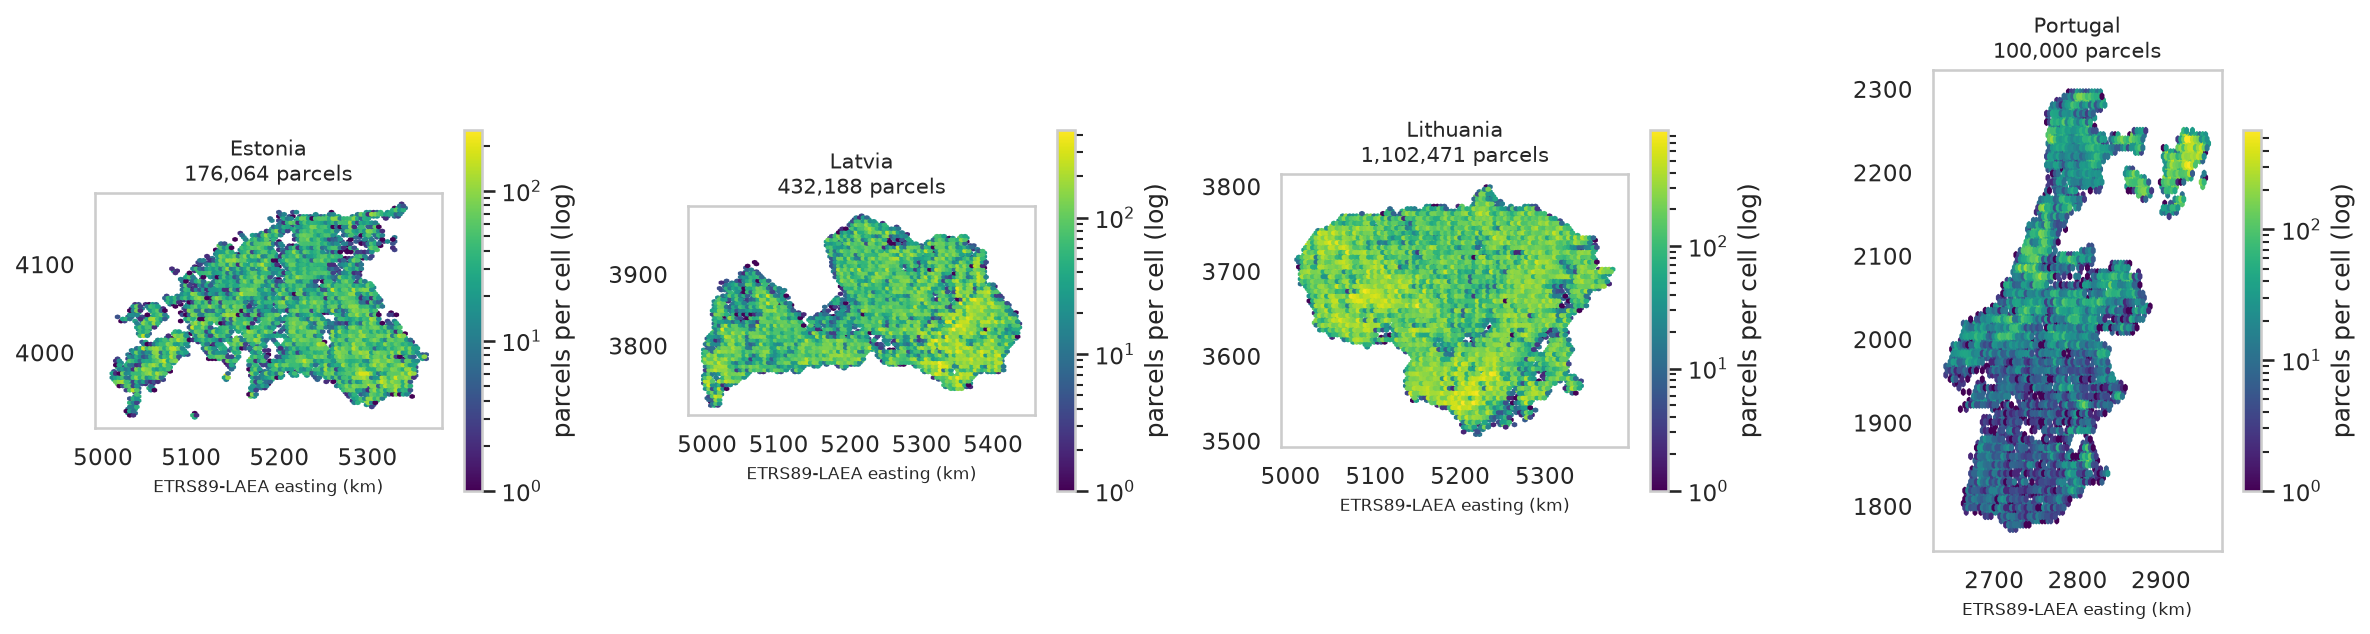

In [12]:
show("08_parcel_density.png", width=1100)

,chips_occupied,chips_for_90pct_of_parcels,median_parcels_per_chip,export_gb_all_chips,export_gb_90pct
Estonia,7425.0,4683.0,20.0,89.4,56.4
Latvia,11588.0,7319.0,31.0,139.5,88.1
Lithuania,12536.0,8063.0,74.0,151.0,97.1
Portugal,9908.0,5155.0,5.0,119.3,62.1



assumptions behind the export estimate:
{
 "chip_px": 224,
 "pixel_m": 10.0,
 "chip_m": 2240.0,
 "crs": "EPSG:3035",
 "bands": 10,
 "timesteps": 12,
 "bytes_per_value": 2,
 "gb_per_chip": 0.012,
 "note": "chips are counted from parcel centroids on a fixed grid, so a parcel straddling a chip edge is counted once"
}


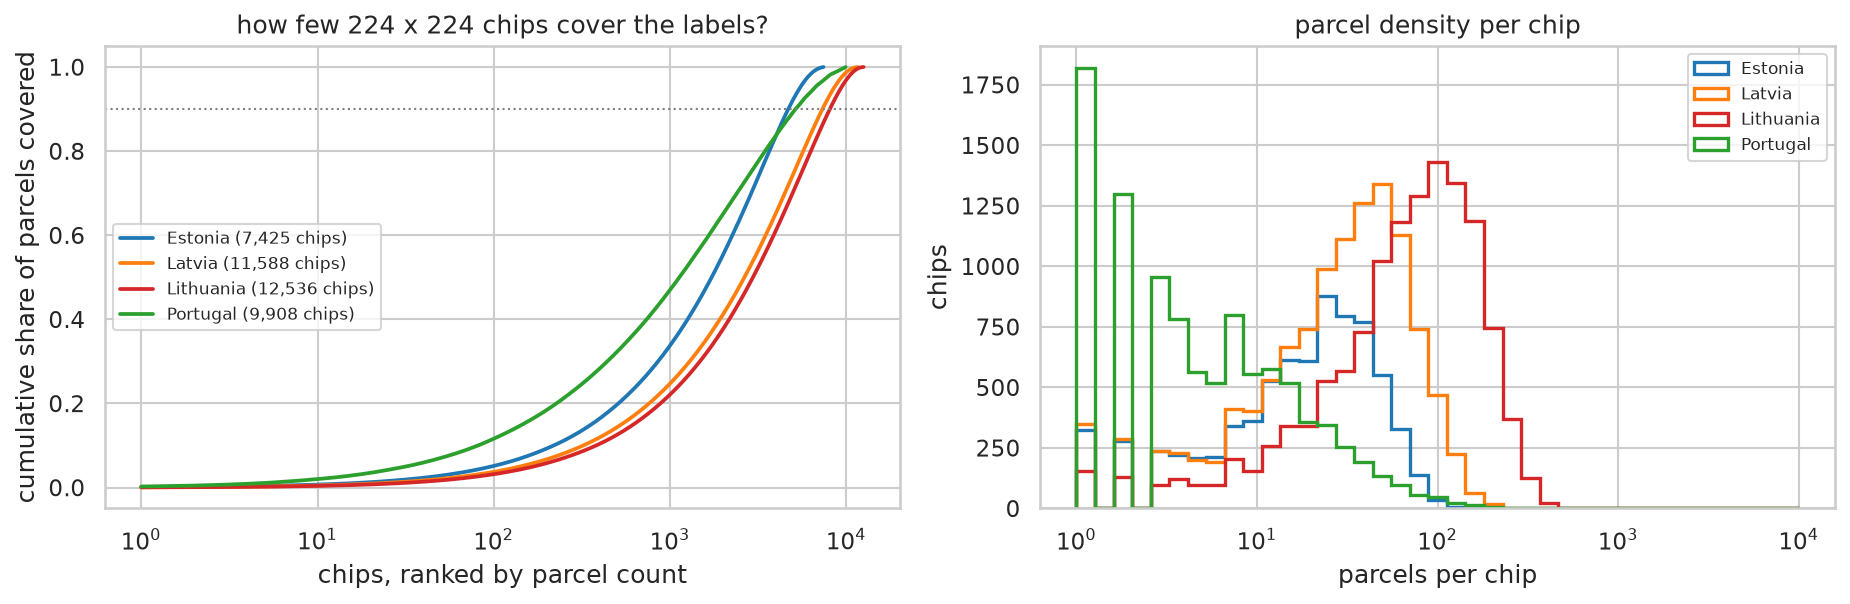

In [13]:
ch = pd.DataFrame(findings["chip_occupancy"]).T
table(ch)
print("\nassumptions behind the export estimate:")
print(json.dumps(findings["chip_assumptions"], indent=1))
show("09_chip_occupancy.png", width=1000)

### 5.1 How many chips does a country cost?

Assigning every parcel centroid to a fixed 2,240 m grid, the declared parcels occupy 7,425 chips in Estonia, 11,588 in Latvia, 12,536 in Lithuania and 9,908 in Portugal. Ninety per cent of the parcels sit in the densest 4,683, 7,319, 8,063 and 5,155 chips respectively.

At twelve monthly composites, ten 10 m bands and int16, one chip is 12.0 MB, so a full Estonian export is about 89 GB and a full Latvian one about 140 GB. **Estonia and Latvia together are roughly 229 GB**, which is more than twice the 100 GB estimate carried in `CLAUDE.md`. Restricting each country to the chips holding ninety per cent of its parcels brings the pair down to about 144 GB, and that is the cheapest lever available before the temporal grid or the band list is touched.

Portugal is the opposite problem: its parcels are small and scattered, so it occupies 9,908 chips, more than Estonia, for one sixth of Estonia's parcels and a median of 5 parcels per chip. A Portuguese chip is mostly unlabelled ground.

## 6. EuroCrops against EuroCropsML

The thesis uses both releases: the vector release supplies the polygons that are rasterised into training masks, and EuroCropsML supplies the per-parcel time series and the official few-shot splits that Track B reproduces. They describe the same 2021 declarations, which raises an obvious question: are they the same data?

,eurocrops_parcels,eurocropsml_raw_labels,eurocropsml_npz,eurocrops_classes,eurocropsml_classes,npz_classes,nuts3_regions
Estonia,176064,176055,175906,128,127,127,5
Latvia,432188,431174,431143,108,103,103,6
Portugal,100000,100000,99634,84,79,79,23


total .npz files in EuroCropsML: 706,683


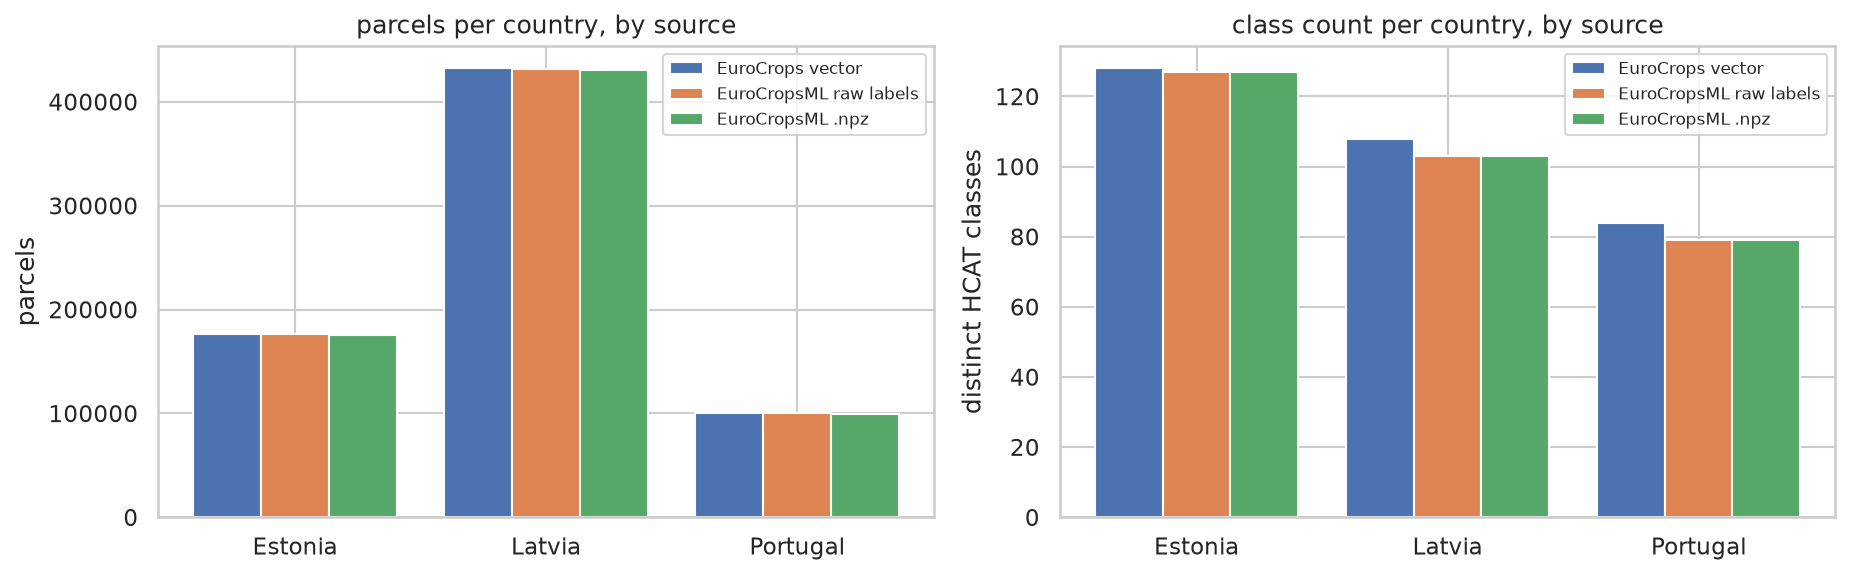

In [14]:
table(pd.DataFrame(comparison["source_inventory"]).T)
print("total .npz files in EuroCropsML:", f"{comparison['npz_total']:,}")
show("13_source_inventory.png", width=1000)

### 6.1 Inventory

EuroCropsML holds 175,906 Estonian, 431,143 Latvian and 99,634 Portuguese `.npz` files, 706,683 in total, against 176,064, 432,188 and 100,000 polygons in the vector release. The attrition into the benchmark is small, and it happens in two places: a handful of parcels have no usable observation series, and Portugal loses 366 parcels between its label table and its `.npz` set.

The class counts differ more than the parcel counts, 108 against 103 for Latvia, which is the first sign that the two releases do not carry the same taxonomy.

,in_both,eurocrops_only,eurocropsml_only,npz_not_in_eurocrops,eurocrops_with_npz
Estonia,176055,9,0,0,175906
Latvia,431174,9,0,0,431143
Portugal,100000,0,0,0,99634


{
 "Estonia": {
  "join_key": "pollu_id",
  "match_rate_pct": 100.0,
  "candidates": {
   "pollu_id": 100.0
  }
 },
 "Latvia": {
  "join_key": "PARCEL_ID",
  "match_rate_pct": 100.0,
  "candidates": {
   "PARCEL_ID": 100.0,
   "OBJECTID": 0.0
  }
 },
 "Portugal": {
  "join_key": "OSA_ID",
  "match_rate_pct": 100.0,
  "candidates": {
   "OSA_ID": 100.0,
   "PAR_ID": 0.0,
   "OSA_NUM": 0.0
  }
 }
}


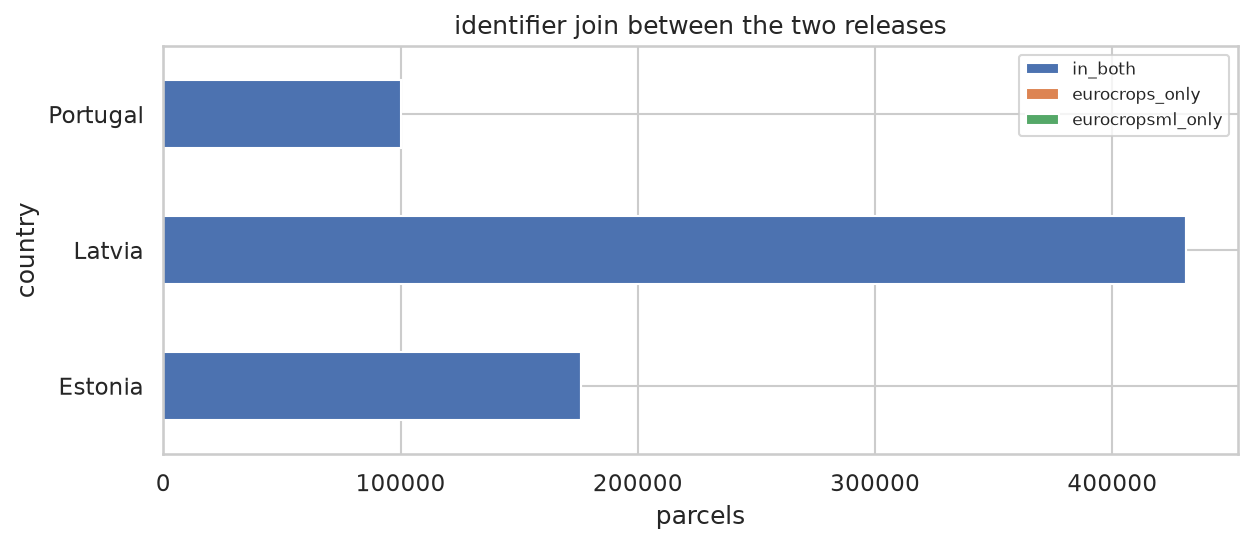

In [15]:
table(pd.DataFrame(comparison["identifier_join"]).T)
print(json.dumps(comparison["join_keys"], indent=1))
show("14_identifier_join.png", width=820)

### 6.2 The identifiers join completely

EuroCropsML's `parcel_id`, the same identifier that appears in the `.npz` filename `<NUTS3>_<parcelID>_<EC_hcat_c>.npz`, joins onto the vector release at **100 %** for all three countries: `pollu_id` for Estonia, `PARCEL_ID` for Latvia and `OSA_ID` for Portugal. Only 9 Estonian and 9 Latvian polygons have no counterpart, and no EuroCropsML parcel is missing from the vector release.

One practical trap is worth recording, because it cost an iteration here: **Portugal's `OSA_ID` is stored as a float in the shapefile**, so a naive string cast produces `"228.0"` against EuroCropsML's `228` and the join silently returns nothing. Identifiers must be normalised through a numeric type before they are compared; `normalise_id()` in `_vector_analysis.py` does this.

,joined_parcels,identical_hcat_pct
Estonia,176055,96.97
Latvia,432179,83.846
Portugal,100000,97.456



largest label disagreements, EuroCrops v11 against EuroCropsML


,country,hcat_name,hcat,EC_hcat_n,EC_hcat_c,parcels
0,Estonia,poaceae_grasses,3301090200,pasture_meadow_grassland_grass,3302000000,2862
1,Estonia,summer_rapeseed_rape,3301060403,spring_rapeseed_rape,3301060402,1236
2,Estonia,legumes_harvested_green,3301090300,pasture_meadow_grassland_grass,3302000000,388
3,Estonia,phacelia,3301061400,not_known_and_other,3399000000,229
4,Estonia,unspecified_legumes_harvested_green,3301090398,legumes_dried_pulses_protein_crops,3301020000,202
31,Latvia,poaceae_grasses,3301090200,pasture_meadow_grassland_grass,3302000000,41522
32,Latvia,arable_crops,3301000000,other_arable_land_crops,3301990000,18842
33,Latvia,orchards_fruits,3303010000,berries_berry_species,3303020000,3251
34,Latvia,plants_harvested_green,3301090000,pasture_meadow_grassland_grass,3302000000,2532
35,Latvia,legumes_dried_pulses_protein_crops,3301020000,unspecified_cereals,3301011500,1693


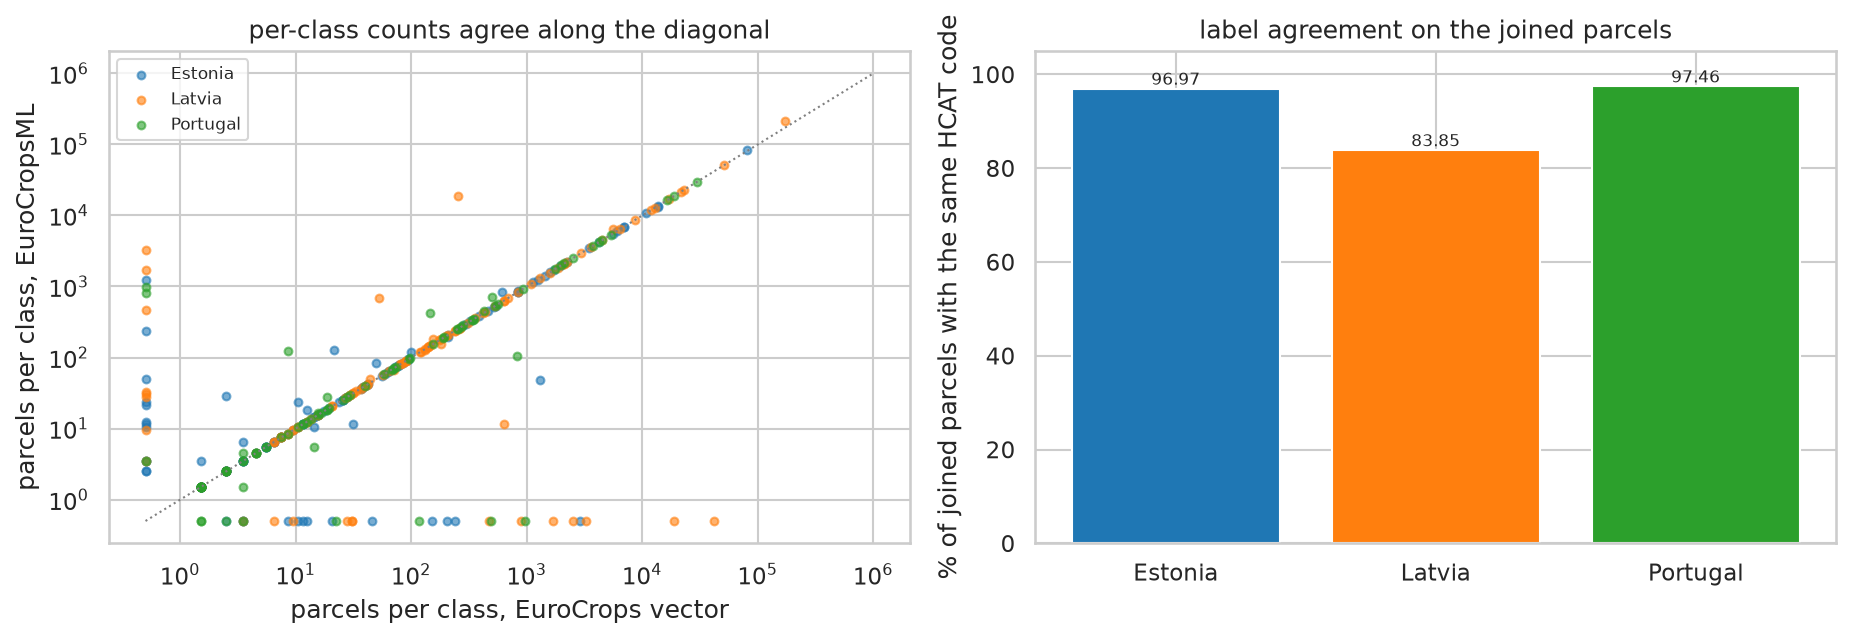

In [16]:
table(pd.DataFrame(comparison["label_agreement"]).T[["joined_parcels", "identical_hcat_pct"]])
mis = cached(CACHE / "ml_label_mismatches.parquet", "_ml_comparison.py")
print("\nlargest label disagreements, EuroCrops v11 against EuroCropsML")
table(mis.groupby("country").head(5)[["country", "hcat_name", "hcat", "EC_hcat_n", "EC_hcat_c", "parcels"]], n=15)
show("15_class_agreement.png", width=1000)

### 6.3 The labels do not agree, and Latvia is the worst case

On the joined parcels the two releases assign the identical HCAT code to 97.0 % of Estonian parcels, 97.5 % of Portuguese ones and only **83.8 % of Latvian ones**. Roughly one Latvian parcel in six carries a different crop label depending on which release is read.

The disagreements are not random. They are taxonomy revisions:

- 41,522 Latvian parcels are `poaceae_grasses` in EuroCrops v11 and `pasture_meadow_grassland_grass` in EuroCropsML, a move from an arable-crop code to a grassland code;
- 18,842 move from the generic `arable_crops` to `other_arable_land_crops`;
- in Estonia the largest group is the same grassland remapping (2,862 parcels), followed by `summer_rapeseed_rape` becoming `spring_rapeseed_rape` (1,236 parcels), which is exactly the spring-and-summer merge the EuroCrops changelog lists for HCAT3.

**EuroCropsML was built on HCAT2, this release carries HCAT3.** The consequence for Phase 1 is direct: the class scheme in `configs/class_scheme_eurocropsml.yaml` was derived from HCAT2 labels, so it cannot be applied to HCAT3 polygons without a remapping, and any comparison against published EuroCropsML numbers must state which taxonomy the labels came from. The mapping tables for both versions ship with the release as `HCAT2.csv` and `HCAT3.csv` and are already on disk under `data/eurocrops/raw/`.

,n_compared,median_iou,share_iou_above_0.99_pct,share_iou_below_0.5_pct,median_area_ratio_ml_over_ec
Estonia,5000.0,1.0,100.0,0.0,1.0
Latvia,5014.0,1.0,100.0,0.0,1.0
Portugal,5000.0,1.0,100.0,0.0,1.0


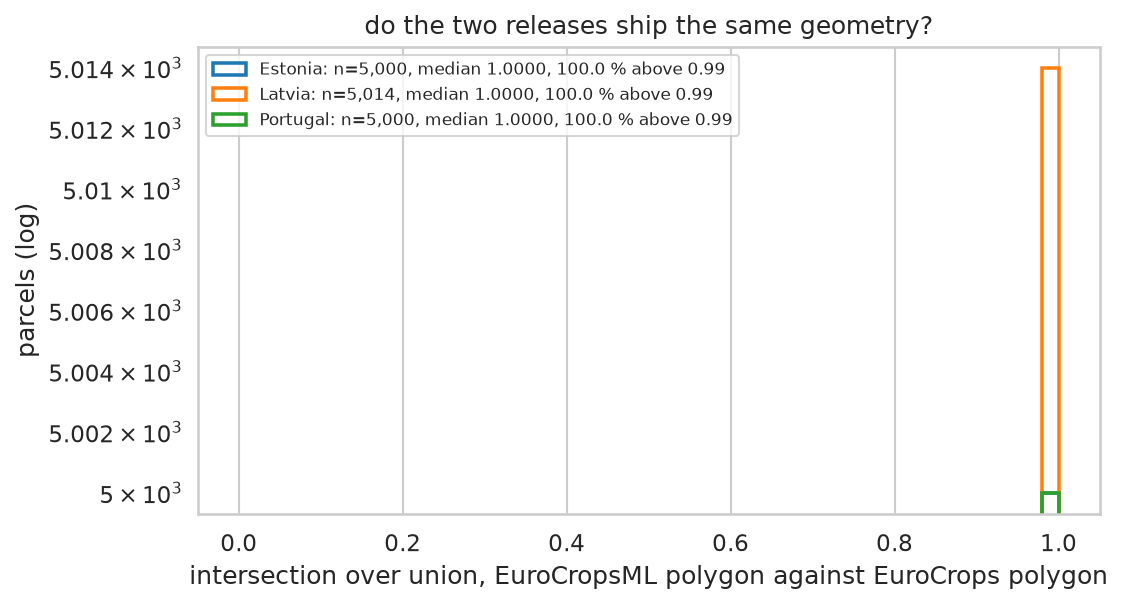

In [17]:
table(pd.DataFrame(comparison["geometry_agreement"]).T)
show("17_geometry_agreement.png", width=780)

### 6.4 The geometries are identical

On a seeded sample of 5,000 parcels per country, the polygon EuroCropsML ships in `raw_data/geometries/<Country>.geojson` and the polygon in the EuroCrops vector release have a **median intersection over union of 1.0**, with 100 % of Estonian, 100 % of Latvian and 100 % of Portuguese parcels above 0.99.

Two things follow. First, **EuroCropsML does ship parcel geometries**, contrary to the note in `CLAUDE.md` that it carries none; they sit in `raw_data.zip`, not in the `preprocess/` tree that the benchmark's own loader uses. Second, since the geometries are the same objects, the rasterised training masks can be built from either source, and the choice between them is a choice of **taxonomy** (83.8 % agreement in Latvia) and of **country coverage** (Lithuania exists only in the vector release), not a choice of geometry.

,dropped_parcels,dropped_pct,median_pixels_kept,median_pixels_dropped
Estonia,9,0.01,255.2,328.9
Latvia,9,0.0,185.8,211.3
Portugal,0,0.0,22.8,None


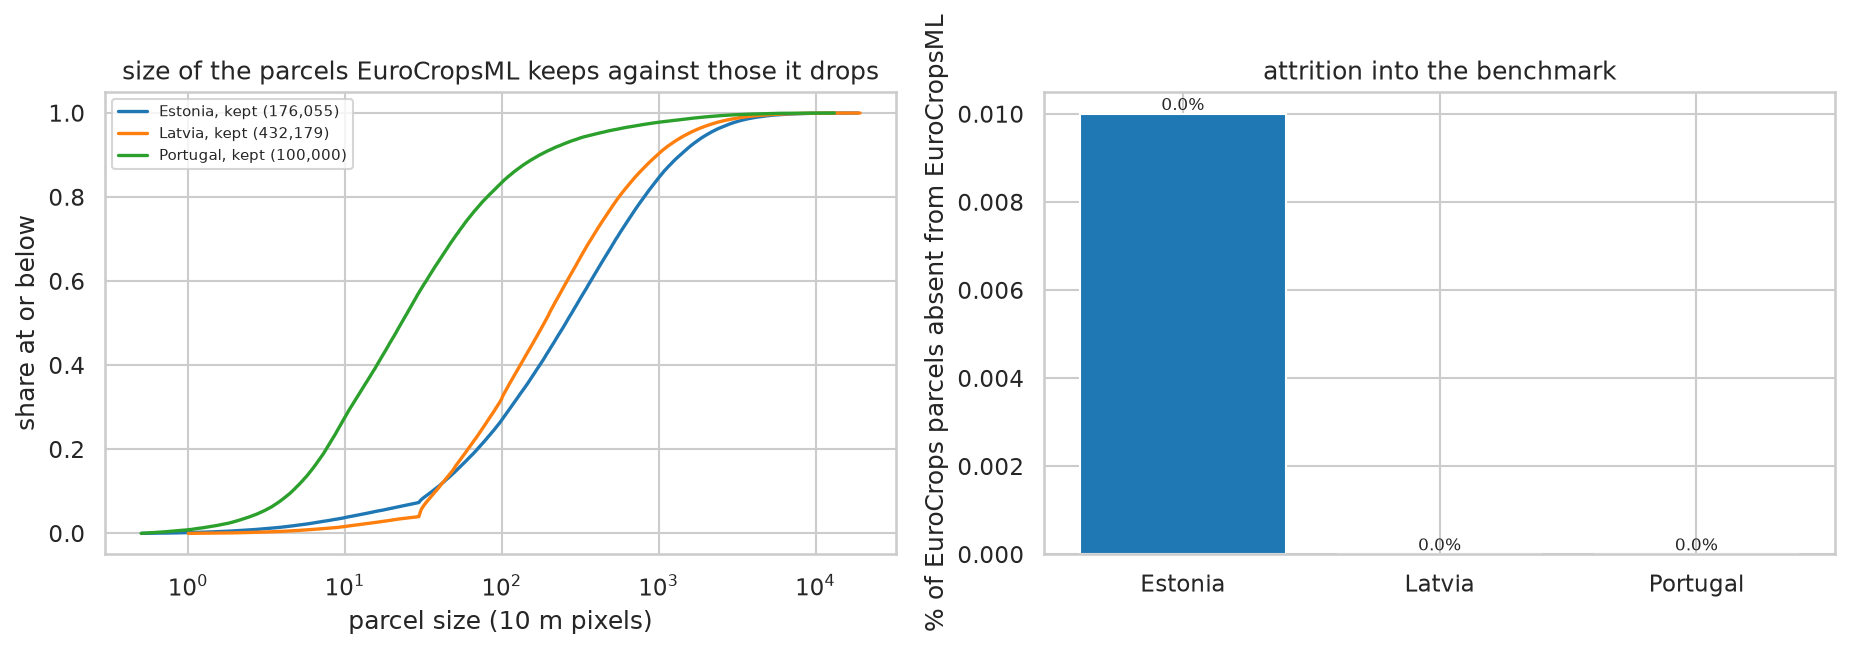

In [18]:
table(pd.DataFrame(comparison["attrition"]).T[["dropped_parcels", "dropped_pct",
                                               "median_pixels_kept", "median_pixels_dropped"]])
show("16_dropped_parcels.png", width=1000)

official EuroCropsML use cases: ['latvia_portugal_vs_estonia', 'latvia_vs_estonia', 'overlap_latvia_portugal_vs_estonia', 'overlap_latvia_vs_estonia']


train   val   test
use_case                           K                       
latvia_portugal_vs_estonia         1       123  1000  35182
                                   5       486  1000  35182
                                   10      840  1000  35182
                                   20     1402  1000  35182
                                   100    4393  1000  35182
                                   200    7264  1000  35182
                                   500   14179  1000  35182
                                   all  105543  1000  35182
latvia_vs_estonia                  1       123  1000  35182
                                   5       486  1000  35182
                                   10      840  1000  35182
                                   20     1402  1000  35182
                                   100    4393  1000  35182
                                   200    7264  1000  35182
                                   500   14179  1000  35182
                                   all  105543  1000  35182
overlap_latvia_portugal_vs_estonia 1       123  1000  35182
                                   5       486  1000  35182
                                   10      840  1000  35182
                                   20     1402  1000  35182
                                   100    4393  1000  35182
                                   200    7264  1000  35182
                                   500   14179  1000  35182
                                   all  105543  1000  35182
overlap_latvia_vs_estonia          1       123  1000  35182
                                   5       486  1000  35182
                                   10      840  1000  35182
                                   20     1402  1000  35182
                                   100    4393  1000  35182
                                   200    7264  1000  35182
                                   500   14179  1000  35182
                                   all  105543  1000  35182

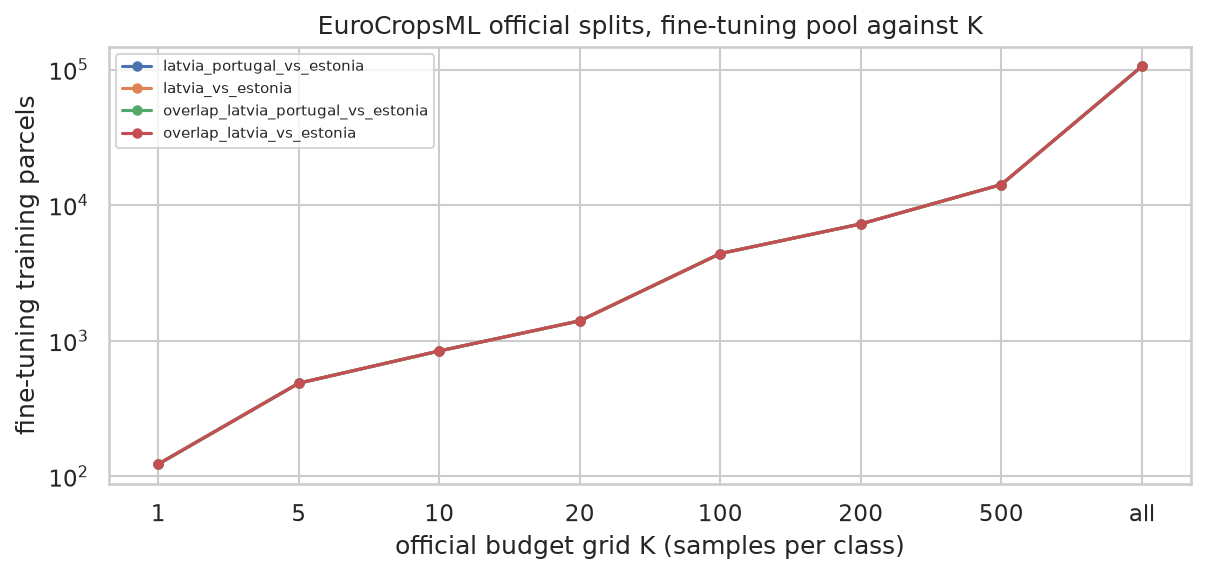

In [19]:
splits = comparison["official_splits"]
print("official EuroCropsML use cases:", list(splits))
rows = []
for case, d in splits.items():
    for k, s in d["finetune_sizes"].items():
        if isinstance(s, dict):
            rows.append({"use_case": case, "K": k, **s})
sp = pd.DataFrame(rows)
order = ["1", "5", "10", "20", "100", "200", "500", "all"]
sp["K"] = pd.Categorical(sp["K"], categories=order, ordered=True)
table(sp.sort_values(["use_case", "K"]).set_index(["use_case", "K"]))
show("18_official_splits.png", width=820)

### 6.5 The official splits

Four use cases ship with EuroCropsML: `latvia_vs_estonia` and `latvia_portugal_vs_estonia`, each also in an `overlap_` variant restricted to the classes shared between the pre-training and fine-tuning countries. The official budget grid is **K in 1, 5, 10, 20, 100, 200, 500 and all**, with a fixed validation set of 1,000 parcels and a fixed test set of 35,182 Estonian parcels at every budget.

This confirms decision D2 of `docs/phase1/protocol.md`: the thesis grid extends the official one with an intermediate point at 50, and the fixed test partition means Track B can be reproduced exactly while Track A adds the spatial blocking the official splits do not provide.

## 7. Conclusions and consequences for Phase 1

1. **The data are on disk and verified.** Four countries, all 2021, 1,810,723 polygons, md5-checked against Zenodo, converted to GeoParquet with the native CRS preserved and a per-country summary recorded. EuroCropsML is beside them, with its geometries, labels, official splits and the packed `.npz` archive.

2. **One polygon is not one label.** The median parcel is 255 pixels in Estonia and 23 in Portugal, so a budget of K polygons per class is a different amount of supervision in each country. Every learning curve must report both units.

3. **Boundaries dominate.** The median parcel has 34 % (Estonia) to 100 % (Portugal) of its area within one pixel of an edge. Macro-F1 should be reported over all labelled pixels and over interior pixels separately.

4. **The class prior depends on the weighting.** Count-weighted and area-weighted priors differ systematically, and a pixel loss inherits the area prior. The weighting decision belongs in the protocol, fixed across models.

5. **Portugal and Lithuania each break an assumption.** Portugal reports areas in square metres, stores its identifier as a float, is exactly 100,000 features and has parcels too small to supervise densely. Lithuania has no parcel identifier and only 22 classes. Neither is fatal, but both must be handled explicitly rather than discovered later.

6. **The two releases share geometries and identifiers but not labels.** The join is complete and the polygons are identical, yet only 83.8 % of Latvian parcels carry the same HCAT code in both, because EuroCropsML is HCAT2 and this release is HCAT3. A remapping is needed before `configs/class_scheme_eurocropsml.yaml` can be applied to these polygons, and every reported number must say which taxonomy it used.

7. **The export is larger than planned.** Estonia and Latvia together are about 229 GB of chips under the current assumptions, against the 100 GB in `CLAUDE.md`. Restricting to the chips that hold ninety per cent of the parcels is the first lever, before the temporal grid or the band list is reduced.